# TopoLines

Turn images into topographic contour lines via the eikonal equation (Verbeek & Verwer grey-weighted distance / Schroeder & Möller look):

1. Grayscale → normalize → slight Gaussian blur  
2. Build a speed field from intensity (`speed = ε + image`)  
3. Place seed point(s)  
4. Solve `|∇T| = 1/speed` with **scikit-fmm** (monotone fast marching)  
5. Draw iso-contours of the travel-time field `T` as thin lines  

**Do not** use `scipy.ndimage.distance_transform_edt` — that ignores the speed field.

In [38]:
# If packages are missing, create/use the project venv then install:
#   python3.12 -m venv .venv
#   .venv/bin/pip install -r requirements.txt
#   .venv/bin/python -m ipykernel install --user --name topolines --display-name "TopoLines"
# Select kernel "TopoLines" (or this folder's .venv) in the notebook UI.
#
# %pip install scikit-fmm scikit-image matplotlib pillow numpy scipy

import skfmm  # noqa: F401 — fail early if the kernel is wrong
print("skfmm", getattr(skfmm, "__version__", "ok"))

skfmm 2025.06.23


In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import skfmm
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage import measure

IMAGE_PATH = Path("lena.png")
BLUR_SIGMA = 1.0          # light blur so pixel noise doesn't spawn bogus wavefronts
SPEED_EPS = 0.1           # keep speed > 0 to avoid infinite travel time
STRIPE_SPACING = 8.0      # L — main tuning knob (smaller → denser stripes)
SEED_MODE = "center"      # "center" | "scatter" | "edge"
N_SCATTER = 5             # used when SEED_MODE == "scatter"
FIGSIZE = (12, 5)

## 1. Load, grayscale, normalize, blur

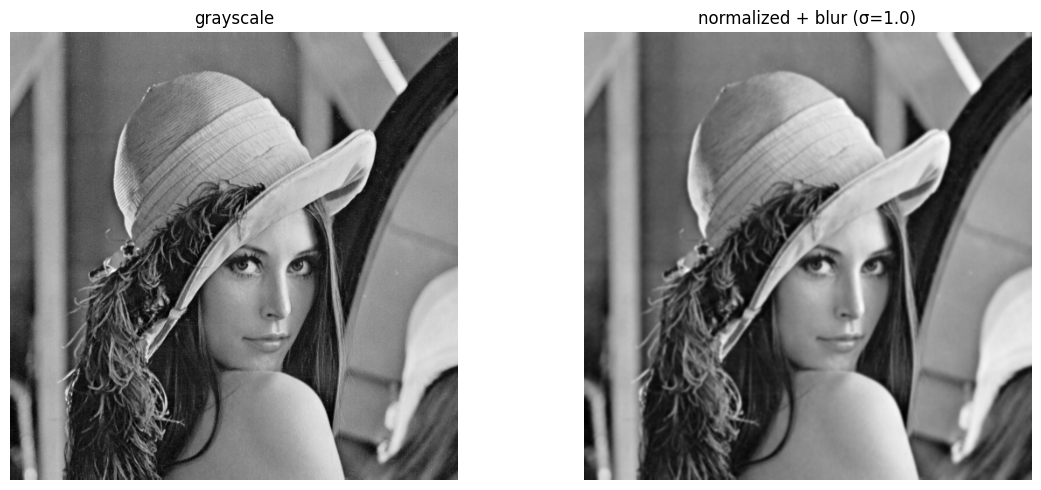

shape=(512, 512), range=[0.020, 0.939]


In [40]:
def load_grayscale(path: Path) -> np.ndarray:
    """Load image as float intensity in [0, 1]."""
    rgb = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64)
    # Luminance weights (Rec. 601)
    gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    gray = gray / 255.0
    return np.clip(gray, 0.0, 1.0)


def preprocess(image: np.ndarray, blur_sigma: float = BLUR_SIGMA) -> np.ndarray:
    """Normalize and lightly blur. Skip blur → noisy local wavefront junk."""
    img = image.astype(np.float64)
    lo, hi = img.min(), img.max()
    if hi > lo:
        img = (img - lo) / (hi - lo)
    if blur_sigma > 0:
        img = gaussian_filter(img, sigma=blur_sigma)
        img = np.clip(img, 0.0, 1.0)
    return img


raw = load_grayscale(IMAGE_PATH)
image = preprocess(raw)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].imshow(raw, cmap="gray")
axes[0].set_title("grayscale")
axes[0].axis("off")
axes[1].imshow(image, cmap="gray")
axes[1].set_title(f"normalized + blur (σ={BLUR_SIGMA})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"shape={image.shape}, range=[{image.min():.3f}, {image.max():.3f}]")

## 2–3. Speed field + seed points

Bright pixels → faster wavefront travel. Seeds mark where the wave starts (`phi = -1`).

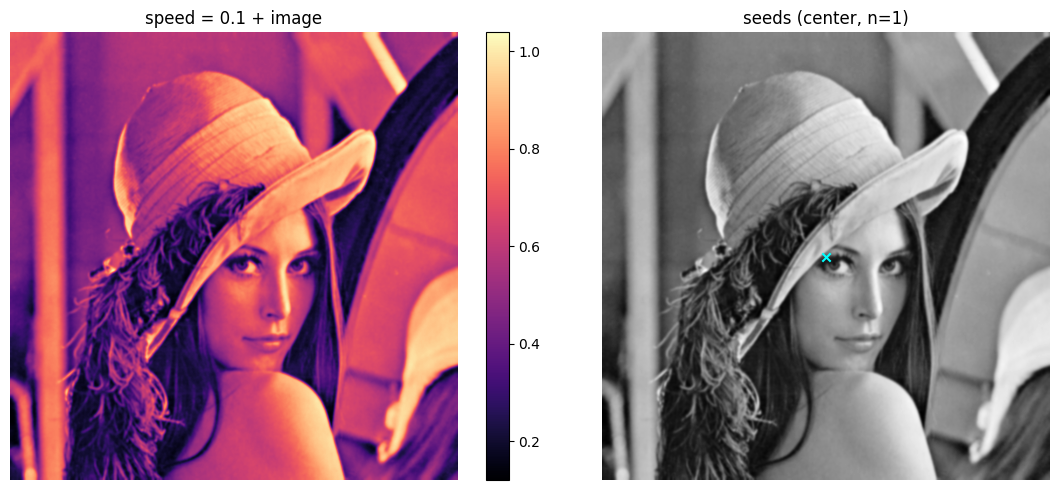

In [41]:
def make_speed(image: np.ndarray, eps: float = SPEED_EPS) -> np.ndarray:
    """speed = eps + intensity; never allow 0 (→ ∞ travel time)."""
    return eps + image


def make_seeds(
    shape: tuple[int, int],
    mode: str = SEED_MODE,
    n_scatter: int = N_SCATTER,
    rng: np.random.Generator | None = None,
) -> list[tuple[int, int]]:
    """Return (row, col) seed locations.

    - center: radial expansion from image midpoint
    - scatter: a few random interior points
    - edge: seeds along the left edge → roughly parallel flow
    """
    h, w = shape
    if mode == "center":
        return [(h // 2, w // 2)]
    if mode == "scatter":
        rng = rng or np.random.default_rng(0)
        margin = max(8, min(h, w) // 16)
        ys = rng.integers(margin, h - margin, size=n_scatter)
        xs = rng.integers(margin, w - margin, size=n_scatter)
        return list(zip(ys.tolist(), xs.tolist()))
    if mode == "edge":
        # Dense seeds along left edge give nearly planar wavefronts
        step = max(1, h // 64)
        return [(y, 0) for y in range(0, h, step)]
    raise ValueError(f"unknown SEED_MODE: {mode!r}")


def make_phi(shape: tuple[int, int], seeds: list[tuple[int, int]]) -> np.ndarray:
    """Narrow-band mask for skfmm: -1 at seeds, +1 elsewhere."""
    phi = np.ones(shape, dtype=np.float64)
    for y, x in seeds:
        phi[y, x] = -1.0
    return phi


speed = make_speed(image)
seeds = make_seeds(image.shape, mode=SEED_MODE)
phi = make_phi(image.shape, seeds)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
im0 = axes[0].imshow(speed, cmap="magma")
axes[0].set_title(f"speed = {SPEED_EPS} + image")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(image, cmap="gray")
sy, sx = zip(*seeds)
axes[1].scatter(sx, sy, c="cyan", s=36, marker="x", linewidths=1.5, zorder=3)
axes[1].set_title(f"seeds ({SEED_MODE}, n={len(seeds)})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Solve the eikonal equation with scikit-fmm

`skfmm.travel_time` is a proper upwind / fast-marching solver of `|∇T| = 1/speed`.

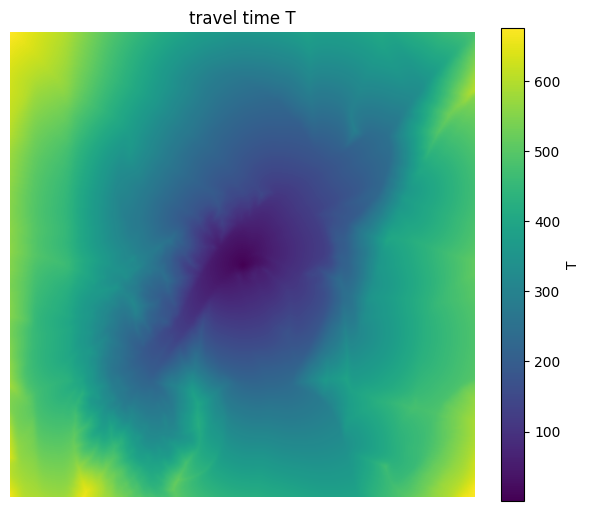

T range=[0.861, 676.271]


In [42]:
def solve_eikonal(phi: np.ndarray, speed: np.ndarray) -> np.ndarray:
    """Travel-time field T from seeds through the speed medium."""
    return skfmm.travel_time(phi, speed)


T = solve_eikonal(phi, speed)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(T, cmap="viridis")
ax.set_title("travel time T")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, label="T")
plt.tight_layout()
plt.show()

print(f"T range=[{T.min():.3f}, {T.max():.3f}]")

## 5. TopoLines from iso-contours of T

Vector contours (cleanest) via `skimage.measure.find_contours`, plus an optional raster preview using `cos(2πT/L)`.

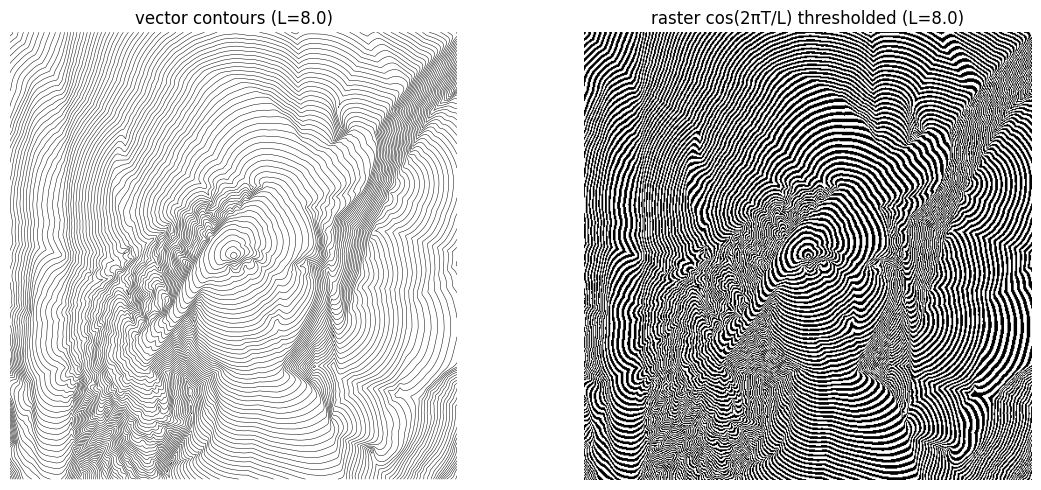

207 contour polylines at spacing L=8.0


In [43]:
def extract_contours(T: np.ndarray, L: float) -> list[np.ndarray]:
    """Iso-contours of T at levels 0, L, 2L, ..."""
    levels = np.arange(0.0, float(np.nanmax(T)), L)
    contours: list[np.ndarray] = []
    for level in levels:
        contours.extend(measure.find_contours(T, level))
    return contours


def plot_vector_stripes(
    T: np.ndarray,
    L: float,
    ax=None,
    color: str = "black",
    linewidth: float = 0.4,
    bg=None,
):
    """Draw thin contour lines of T — the TopoLines topographic line look."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    if bg is not None:
        ax.imshow(bg, cmap="gray", alpha=0.25)
    else:
        ax.set_facecolor("white")
        ax.set_xlim(0, T.shape[1])
        ax.set_ylim(T.shape[0], 0)  # image coords: y down
    for contour in extract_contours(T, L):
        # find_contours returns (row, col) == (y, x)
        ax.plot(contour[:, 1], contour[:, 0], color=color, lw=linewidth, solid_capstyle="round")
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


def raster_stripes(T: np.ndarray, L: float) -> np.ndarray:
    """Raster preview: cos(2πT/L). Threshold for hard stripes; softer midtones for AA-ish look."""
    return np.cos(2.0 * np.pi * T / L)


contours = extract_contours(T, STRIPE_SPACING)
raster = raster_stripes(T, STRIPE_SPACING)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

plot_vector_stripes(T, STRIPE_SPACING, ax=axes[0], linewidth=0.35)
axes[0].set_title(f"vector contours (L={STRIPE_SPACING})")

axes[1].imshow(raster > 0, cmap="gray")
axes[1].set_title(f"raster cos(2πT/L) thresholded (L={STRIPE_SPACING})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"{len(contours)} contour polylines at spacing L={STRIPE_SPACING}")

## End-to-end helper + seed-mode comparison

`topolines` wraps the full pipeline. Re-run with different `seed_mode` / `L` to tune.

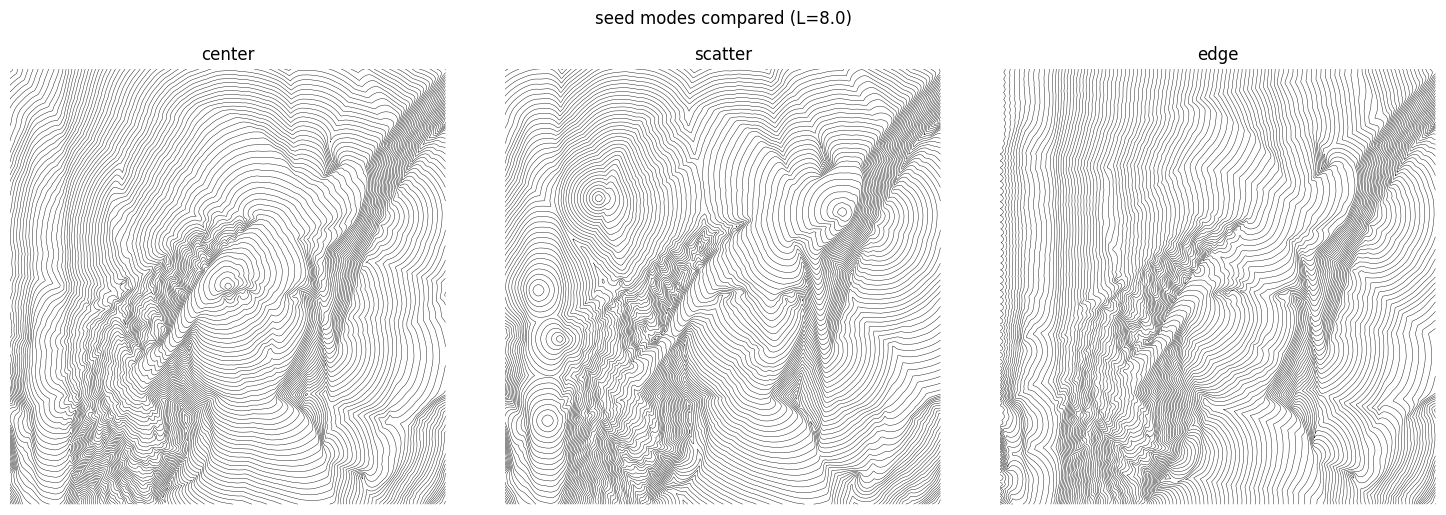

In [44]:
def topolines(
    path: Path | str,
    *,
    blur_sigma: float = BLUR_SIGMA,
    speed_eps: float = SPEED_EPS,
    seed_mode: str = SEED_MODE,
    n_scatter: int = N_SCATTER,
    L: float = STRIPE_SPACING,
    linewidth: float = 0.35,
    show: bool = True,
):
    """Full pipeline: image → T → vector stripe plot."""
    raw = load_grayscale(Path(path))
    img = preprocess(raw, blur_sigma=blur_sigma)
    spd = make_speed(img, eps=speed_eps)
    seeds = make_seeds(img.shape, mode=seed_mode, n_scatter=n_scatter)
    phi = make_phi(img.shape, seeds)
    travel = solve_eikonal(phi, spd)

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img, cmap="gray")
        sy, sx = zip(*seeds)
        axes[0].scatter(sx, sy, c="cyan", s=28, marker="x", linewidths=1.2)
        axes[0].set_title(f"input + seeds ({seed_mode})")
        axes[0].axis("off")

        im = axes[1].imshow(travel, cmap="viridis")
        axes[1].set_title("travel time T")
        axes[1].axis("off")
        plt.colorbar(im, ax=axes[1], fraction=0.046)

        plot_vector_stripes(travel, L, ax=axes[2], linewidth=linewidth)
        axes[2].set_title(f"TopoLines (L={L})")
        plt.tight_layout()
        plt.show()

    return travel, seeds


# Compare the three seed layouts side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mode in zip(axes, ("center", "scatter", "edge")):
    travel, _ = topolines(IMAGE_PATH, seed_mode=mode, L=STRIPE_SPACING, show=False)
    plot_vector_stripes(travel, STRIPE_SPACING, ax=ax, linewidth=0.3)
    ax.set_title(mode)
plt.suptitle(f"seed modes compared (L={STRIPE_SPACING})", y=1.02)
plt.tight_layout()
plt.show()

## Playground — tweak modifiers

Drag the sliders (or edit values) and watch the stripes update.  
`L` densifies/thins stripes; blur cleans noise; `ε` flattens contrast in the speed field; seed mode changes the whole flow.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── knobs ──────────────────────────────────────────────────────────────
# Re-run this cell after changing code above. Use the widgets below to explore.
w_blur = widgets.FloatSlider(
    value=BLUR_SIGMA, min=0.0, max=5.0, step=0.25,
    description="blur σ", continuous_update=False,
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
    tooltip="Higher → smoother speed field, fewer noisy wiggles in stripes",
)
w_eps = widgets.FloatSlider(
    value=SPEED_EPS, min=0.01, max=1.0, step=0.01,
    description="speed ε", continuous_update=False,
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
    tooltip="Floor on speed. Higher → more uniform travel, less image-driven distortion",
)
w_L = widgets.FloatSlider(
    value=STRIPE_SPACING, min=1.0, max=40.0, step=0.5,
    description="L (spacing)", continuous_update=False,
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
    tooltip="Stripe period. Small → dense/noisy; large → sparse/abstract",
)
w_lw = widgets.FloatSlider(
    value=0.35, min=0.1, max=2.0, step=0.05,
    description="line width", continuous_update=False,
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
)
w_seed = widgets.Dropdown(
    options=[("center (radial)", "center"), ("scatter", "scatter"), ("edge (parallel flow)", "edge")],
    value=SEED_MODE,
    description="seed mode",
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
)
w_n = widgets.IntSlider(
    value=N_SCATTER, min=1, max=20, step=1,
    description="# scatter", continuous_update=False,
    style={"description_width": "90px"}, layout=widgets.Layout(width="420px"),
    tooltip="Only used when seed mode is scatter",
)
w_invert = widgets.Checkbox(
    value=False,
    description="invert speed (dark = fast)",
    indent=False,
)
w_show_T = widgets.Checkbox(
    value=True,
    description="show travel-time field",
    indent=False,
)
w_overlay = widgets.Checkbox(
    value=False,
    description="ghost original under TopoLines",
    indent=False,
)

out = widgets.Output()


def _render(_=None):
    with out:
        clear_output(wait=True)
        raw = load_grayscale(IMAGE_PATH)
        img = preprocess(raw, blur_sigma=w_blur.value)

        intensity = (1.0 - img) if w_invert.value else img
        spd = make_speed(intensity, eps=w_eps.value)
        seeds = make_seeds(img.shape, mode=w_seed.value, n_scatter=w_n.value)
        travel = solve_eikonal(make_phi(img.shape, seeds), spd)

        cols = 3 if w_show_T.value else 2
        fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
        axes = list(np.atleast_1d(axes))

        axes[0].imshow(img, cmap="gray")
        sy, sx = zip(*seeds)
        axes[0].scatter(sx, sy, c="cyan", s=36, marker="x", linewidths=1.4, zorder=3)
        axes[0].set_title(f"input + seeds ({w_seed.value})")
        axes[0].axis("off")

        stripe_ax = axes[1]
        if w_show_T.value:
            im = axes[1].imshow(travel, cmap="viridis")
            axes[1].set_title("travel time T")
            axes[1].axis("off")
            plt.colorbar(im, ax=axes[1], fraction=0.046)
            stripe_ax = axes[2]

        bg = img if w_overlay.value else None
        plot_vector_stripes(travel, w_L.value, ax=stripe_ax, linewidth=w_lw.value, bg=bg)
        inv = ", inverted" if w_invert.value else ""
        stripe_ax.set_title(f"TopoLines  L={w_L.value:g}  σ={w_blur.value:g}  ε={w_eps.value:g}{inv}")

        plt.tight_layout()
        plt.show()
        print(
            f"T∈[{travel.min():.1f}, {travel.max():.1f}]  |  "
            f"speed∈[{spd.min():.3f}, {spd.max():.3f}]  |  "
            f"seeds={len(seeds)}"
        )


controls = widgets.VBox([
    widgets.HTML("<b>Modifiers</b> — change any control; plot refreshes on release"),
    w_blur, w_eps, w_L, w_lw, w_seed, w_n,
    widgets.HBox([w_invert, w_show_T, w_overlay]),
])
for w in (w_blur, w_eps, w_L, w_lw, w_seed, w_n, w_invert, w_show_T, w_overlay):
    w.observe(_render, names="value")

display(controls, out)
_render()


Output()

## Playground — fabrication constraints

Same interactive solve, but sized for a physical print:

1. **Min image side = 8″** (pixels → mm via that scale)  
2. **Stroke thickness ∈ [0.1, 1.0] mm**  
3. **Clear gap ≥ 0.1 mm** between neighboring strokes (edge-to-edge in the densest region)

Because `|∇T| = 1/speed`, the tightest contour pitch is `L × speed_min` (in pixels). We clamp `L` so that pitch never drops below `thickness + 0.1 mm`.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── physical print assumptions ─────────────────────────────────────────
PRINT_MIN_INCHES = 8.0       # shorter side of the image on paper
MIN_GAP_MM = 0.1            # clear edge-to-edge gap between strokes
THICK_MM_MIN, THICK_MM_MAX = 0.1, 1.0
DISPLAY_SCALE = 0.4          # notebook preview as a fraction of true print size
MM_PER_INCH = 25.4
PT_PER_INCH = 72.0

_style = {"description_width": "110px"}
_layout = widgets.Layout(width="460px")

fw_blur = widgets.FloatSlider(
    value=BLUR_SIGMA, min=0.0, max=5.0, step=0.25,
    description="blur σ", continuous_update=False, style=_style, layout=_layout,
)
fw_eps = widgets.FloatSlider(
    value=SPEED_EPS, min=0.01, max=1.0, step=0.01,
    description="speed ε", continuous_update=False, style=_style, layout=_layout,
)
fw_L = widgets.FloatSlider(
    value=STRIPE_SPACING, min=0.5, max=80.0, step=0.5,
    description="L (requested)", continuous_update=False, style=_style, layout=_layout,
    tooltip="Travel-time contour period. Auto-clamped to honor min gap.",
)
fw_thick = widgets.FloatSlider(
    value=0.3, min=THICK_MM_MIN, max=THICK_MM_MAX, step=0.05,
    description="thickness mm", continuous_update=False, style=_style, layout=_layout,
    tooltip="Physical stroke width when printed at 8″ min side",
)
fw_seed = widgets.Dropdown(
    options=[("center (radial)", "center"), ("scatter", "scatter"), ("edge (parallel flow)", "edge")],
    value=SEED_MODE, description="seed mode", style=_style, layout=_layout,
)
fw_n = widgets.IntSlider(
    value=N_SCATTER, min=1, max=20, step=1,
    description="# scatter", continuous_update=False, style=_style, layout=_layout,
)
fw_invert = widgets.Checkbox(value=False, description="invert speed (dark = fast)", indent=False)
fw_show_T = widgets.Checkbox(value=True, description="show travel-time field", indent=False)
fw_overlay = widgets.Checkbox(value=False, description="ghost original under TopoLines", indent=False)
fw_info = widgets.HTML(value="")
fw_out = widgets.Output()


def _mm_per_pixel(shape: tuple[int, int]) -> float:
    return PRINT_MIN_INCHES * MM_PER_INCH / min(shape)


def _print_size_inches(shape: tuple[int, int]) -> tuple[float, float]:
    h, w = shape
    m = min(h, w)
    return PRINT_MIN_INCHES * h / m, PRINT_MIN_INCHES * w / m


def _L_min_for_gap(speed_min: float, mm_per_px: float, thickness_mm: float) -> float:
    """Smallest L such that densest iso-contours keep a clear gap of MIN_GAP_MM."""
    # center-to-center pitch (mm) ≈ L * speed * mm_per_px  (since ds = L * speed in px)
    # require pitch ≥ thickness + MIN_GAP_MM  → clear edge gap ≥ MIN_GAP_MM
    min_pitch_mm = thickness_mm + MIN_GAP_MM
    return min_pitch_mm / max(speed_min * mm_per_px, 1e-12)


def _thickness_to_pt(thickness_mm: float) -> float:
    """Stroke width in matplotlib points at true print scale (then scaled for preview)."""
    return (thickness_mm / MM_PER_INCH) * PT_PER_INCH


def _fab_render(_=None):
    with fw_out:
        clear_output(wait=True)
        raw = load_grayscale(IMAGE_PATH)
        img = preprocess(raw, blur_sigma=fw_blur.value)

        intensity = (1.0 - img) if fw_invert.value else img
        spd = make_speed(intensity, eps=fw_eps.value)
        mm_per_px = _mm_per_pixel(img.shape)
        L_floor = _L_min_for_gap(float(spd.min()), mm_per_px, fw_thick.value)

        # Enforce fabrication floor on L
        L_used = max(fw_L.value, L_floor)
        clamped = L_used > fw_L.value + 1e-9

        seeds = make_seeds(img.shape, mode=fw_seed.value, n_scatter=fw_n.value)
        travel = solve_eikonal(make_phi(img.shape, seeds), spd)

        # Densest pitch from the speed field (analytic lower bound)
        pitch_min_mm = L_used * float(spd.min()) * mm_per_px
        gap_min_mm = pitch_min_mm - fw_thick.value
        print_h_in, print_w_in = _print_size_inches(img.shape)
        lw_pt = _thickness_to_pt(fw_thick.value) * DISPLAY_SCALE

        status = (
            f"<b>Print:</b> {print_w_in:.2f}″ × {print_h_in:.2f}″ "
            f"(min side {PRINT_MIN_INCHES:g}″) · {mm_per_px:.4f} mm/px<br>"
            f"<b>Stroke:</b> {fw_thick.value:.2f} mm → { _thickness_to_pt(fw_thick.value):.2f} pt at full size<br>"
            f"<b>L:</b> requested {fw_L.value:g} → used <b>{L_used:.3f}</b> "
            f"(floor {L_floor:.3f} for {MIN_GAP_MM} mm gap @ ε={fw_eps.value:g}"
            f"{', inverted' if fw_invert.value else ''})<br>"
            f"<b>Densest pitch:</b> {pitch_min_mm:.3f} mm center-to-center · "
            f"clear gap ≈ {gap_min_mm:.3f} mm"
        )
        if clamped:
            status += (
                f"<br><span style='color:#b06000'><b>Clamped:</b> requested L too tight — "
                f"raised to {L_used:.3f} so strokes keep ≥ {MIN_GAP_MM} mm clearance.</span>"
            )
        fw_info.value = status

        cols = 3 if fw_show_T.value else 2
        # Preview panels; stripe panel aspect matches the image
        fig, axes = plt.subplots(1, cols, figsize=(4.2 * cols, 4.2 * img.shape[0] / img.shape[1]))
        axes = list(np.atleast_1d(axes))

        axes[0].imshow(img, cmap="gray")
        sy, sx = zip(*seeds)
        axes[0].scatter(sx, sy, c="cyan", s=36, marker="x", linewidths=1.4, zorder=3)
        axes[0].set_title(f"input + seeds ({fw_seed.value})")
        axes[0].axis("off")

        stripe_ax = axes[1]
        if fw_show_T.value:
            im = axes[1].imshow(travel, cmap="viridis")
            axes[1].set_title("travel time T")
            axes[1].axis("off")
            plt.colorbar(im, ax=axes[1], fraction=0.046)
            stripe_ax = axes[2]

        bg = img if fw_overlay.value else None
        plot_vector_stripes(travel, L_used, ax=stripe_ax, linewidth=lw_pt, bg=bg)
        inv = ", inv" if fw_invert.value else ""
        stripe_ax.set_title(
            f"fab TopoLines  L={L_used:.2f}  {fw_thick.value:.2f}mm  "
            f"gap≥{MIN_GAP_MM}mm  σ={fw_blur.value:g}{inv}"
        )

        plt.tight_layout()
        plt.show()
        print(
            f"T∈[{travel.min():.1f}, {travel.max():.1f}]  |  "
            f"speed∈[{spd.min():.3f}, {spd.max():.3f}]  |  "
            f"seeds={len(seeds)}  |  preview={DISPLAY_SCALE:.0%} of print size"
        )


fab_controls = widgets.VBox([
    widgets.HTML(
        "<b>Fabrication playground</b> — thickness in mm; L auto-clamped for "
        f"{MIN_GAP_MM} mm clear gap at {PRINT_MIN_INCHES:g}″ min side"
    ),
    fw_blur, fw_eps, fw_L, fw_thick, fw_seed, fw_n,
    widgets.HBox([fw_invert, fw_show_T, fw_overlay]),
    fw_info,
])
for w in (fw_blur, fw_eps, fw_L, fw_thick, fw_seed, fw_n, fw_invert, fw_show_T, fw_overlay):
    w.observe(_fab_render, names="value")

display(fab_controls, fw_out)
_fab_render()


Output()